In [1]:
# imports
import re
import os
import time
from glob import glob
from os.path import basename

import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import center_of_mass
from scipy.signal import find_peaks
from scipy import ndimage

In [2]:
# choose the data folder

folder = r"G:\Shared drives\XPCS_2026\data\FCGT_12-15-24\h5"

DATASET_PATH = "entry1/instrument_1/detector_1/data"

files = sorted(
    glob(os.path.join(folder, "*.h5")),
    key=os.path.getmtime
)

print(f"Found {len(files)} h5 files")
for i, f in enumerate(files):
    print(f"{i:3d} : {basename(f)}")

Found 20 h5 files
  0 : FCGT_initial_380K_50ms_20images_62faa482-4ffd-4eb7-8f14-59455ce2f750.h5
  1 : FCGT_initial_370K_50ms_50images_f4b6d775-04fb-413f-84ba-e97811ecfe95.h5
  2 : FCGT_initial_365K_50ms_20images_ff58e290-6a97-474a-91ac-860a74328921.h5
  3 : FCGT_initial_360K_10ms_20images_4a557257-5351-46fc-9727-172c475fb335.h5
  4 : FCGT_initial_350K_10ms_20images_073fe2b8-d5e3-45e2-abf1-9e6ad9f244a7.h5
  5 : FCGT_initial_340K_10ms_20images_b226c14d-e92c-462b-9340-d67db6ac50ff.h5
  6 : FCGT_initial_320K_10ms_20images_837710c5-d55b-493b-aaa5-289273ca29eb.h5
  7 : FCGT_initial_310K_10ms_20images_591d1f76-b66b-442d-9021-aca08a9cfa9d.h5
  8 : FCGT_initial_300K_10ms_20images_XMCD_e30274f3-4754-4150-a5da-b1c98104b453.h5
  9 : FCGT_initial_300K_10ms_20images_1b7fce69-29b8-4fde-9b79-bd89f6b8310a.h5
 10 : FCGT_after_cooling_300K_10ms_20images_1c09e527-6db8-410d-9802-f8682e159e7b.h5
 11 : FCGT_363K_XPCS_300ms_1900images_640readout_310d3268-f4c8-48b6-9cb6-9bcc8161909a.h5
 12 : FCGT_350K_XMCD_9c0

In [3]:
# helper functions

def get_temp(filename):
    """Return temperature in K from a filename containing something like 350K."""
    m = re.search(r"(\d+)K", os.path.basename(filename))
    if m:
        return float(m.group(1))
    return np.nan


def read_h5_stack(file, dataset_path=DATASET_PATH, as_float=False):
    """Read the detector data and remove length-1 dimensions like (1, N, Y, X)."""
    with h5py.File(file, "r") as f:
        data = np.squeeze(f[dataset_path][:])
    if as_float:
        data = data.astype(float)
    return data


def average_image_from_file(file, dataset_path=DATASET_PATH):
    """Make an average detector image without changing the file choice elsewhere."""
    data = read_h5_stack(file, dataset_path=dataset_path, as_float=True)
    return np.mean(data, axis=0)


def g2_fft_stationary(signal, max_tau=None):
    """
    Fast g2 from the stationary equation:
        g2(tau) = <I(t) I(t + tau)> / <I>^2

    This uses an FFT autocorrelation, which is much faster than looping over tau.
    tau = 0 is removed because XPCS plots usually start at tau = 1 frame.
    """
    signal = np.asarray(signal, dtype=float)
    signal = signal[np.isfinite(signal)]

    n = len(signal)
    if n < 3:
        raise ValueError("Signal needs at least 3 points.")

    mean_I = np.mean(signal)
    if mean_I == 0:
        raise ValueError("Mean intensity is zero, so g2 cannot be normalized.")

    if max_tau is None:
        max_tau = n // 4

    max_tau = int(min(max_tau, n - 1))

    # zero pad so the FFT gives the linear autocorrelation, not a circular one
    nfft = 1 << (2*n - 1).bit_length()
    f = np.fft.rfft(signal, n=nfft)
    autocorr = np.fft.irfft(f * np.conjugate(f), n=nfft)[:n]

    # for each tau, only n - tau products contribute
    counts = np.arange(n, 0, -1)
    numerator = autocorr / counts

    tau = np.arange(1, max_tau + 1)
    g2_curve = numerator[tau] / (mean_I**2)

    return tau, g2_curve


def g2_direct_stationary(signal, max_tau=None):
    """
    Slower direct version of the same equation.
    This is useful only for checking the FFT result on a short signal.
    """
    signal = np.asarray(signal, dtype=float)
    n = len(signal)

    if max_tau is None:
        max_tau = n // 4

    max_tau = int(min(max_tau, n - 1))
    mean_I = np.mean(signal)

    tau = np.arange(1, max_tau + 1)
    g2_curve = np.array([
        np.mean(signal[:-t] * signal[t:]) / (mean_I**2)
        for t in tau
    ])

    return tau, g2_curve


def roi_signal_from_file(file, roi, dataset_path=DATASET_PATH, chunk_size=100):
    """Return mean intensity vs frame inside a 2D ROI mask."""
    roi = np.asarray(roi, dtype=bool)

    signal = []

    with h5py.File(file, "r") as f:
        dset = f[dataset_path]

        # handles shapes like (1, N, Y, X) and (N, Y, X)
        if dset.ndim == 4 and dset.shape[0] == 1:
            n_frames = dset.shape[1]
            image_shape = dset.shape[2:]
            reader = lambda a, b: dset[0, a:b, :, :]
        elif dset.ndim == 3:
            n_frames = dset.shape[0]
            image_shape = dset.shape[1:]
            reader = lambda a, b: dset[a:b, :, :]
        else:
            raise ValueError(f"Unexpected detector data shape: {dset.shape}")

        if tuple(image_shape) != tuple(roi.shape):
            raise ValueError(f"ROI shape {roi.shape} does not match image shape {image_shape}")

        for start in range(0, n_frames, chunk_size):
            stop = min(start + chunk_size, n_frames)
            frames = reader(start, stop)

            for frame in frames:
                signal.append(frame[roi].mean())

    return np.array(signal, dtype=float)


def plot_g2_for_file(file, roi, max_tau=None, dataset_path=DATASET_PATH):
    """Load an ROI signal, calculate g2, and plot one temperature."""
    start = time.perf_counter()

    signal = roi_signal_from_file(file, roi, dataset_path=dataset_path)
    tau, g2_curve = g2_fft_stationary(signal, max_tau=max_tau)

    temp = get_temp(file)

    plt.figure(figsize=(7, 5))
    plt.semilogx(tau, g2_curve)
    plt.xlabel(r"$\tau$ (frames)")
    plt.ylabel(r"$g^{(2)}(\tau)$")
    plt.title(f"g₂ curve, {temp:.0f} K")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("File:", os.path.basename(file))
    print(f"Mean signal: {np.mean(signal):.3g}")
    print(f"Cell took {time.perf_counter() - start:.2f} s")

    return tau, g2_curve, signal

In [45]:
# choose one file to build the ROI from

xpcs_files = sorted(
    [f for f in files if "XPCS" in os.path.basename(f)],
    key=get_temp
)

print("number of XPCS files:", len(xpcs_files))

for i, f in enumerate(xpcs_files):
    print(f"{i:3d} : {basename(f)}")

roi_file_index = 1  # change this for another file 
file = xpcs_files[roi_file_index]

print("\nChosen ROI file:")
print(os.path.basename(file))

number of XPCS files: 5
  0 : FCGT_350K_XPCS_300ms_1900images_640readout_681083c8-1049-4181-92ae-5a89e07969d8.h5
  1 : FCGT_355K_XPCS_300ms_1900images_640readout_19ccc0d3-79e7-4fd8-b5a3-aefc582d5bc0.h5
  2 : FCGT_360K_XPCS_300ms_1900images_640readout_cd9caa08-abba-4fcd-be88-7cc2f0a4d36c.h5
  3 : FCGT_362K_XPCS_300ms_1900images_640readout_a96aa249-fc0b-47ee-90e1-583a86cdb4cb.h5
  4 : FCGT_363K_XPCS_300ms_1900images_640readout_310d3268-f4c8-48b6-9cb6-9bcc8161909a.h5

Chosen ROI file:
FCGT_355K_XPCS_300ms_1900images_640readout_19ccc0d3-79e7-4fd8-b5a3-aefc582d5bc0.h5


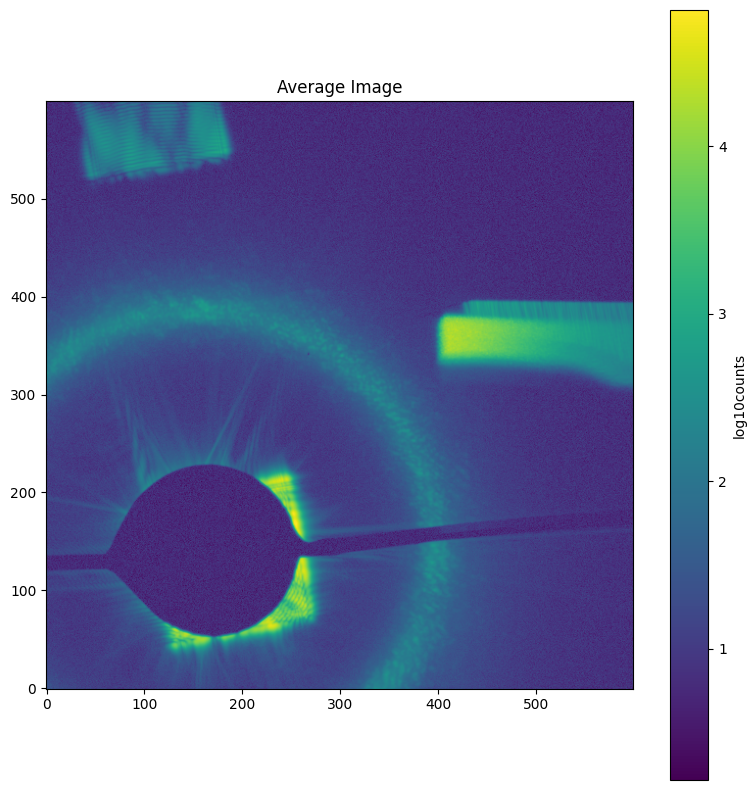

Cell took 10.84 s


In [46]:
# average image for ROI selection

start = time.perf_counter()

avg = average_image_from_file(file)

plt.figure(figsize=(8, 8))
plt.imshow(np.log10(avg + 1), origin="lower")
plt.colorbar(label="log10counts")
plt.title("Average Image")
plt.tight_layout()
plt.show()

print(f"Cell took {time.perf_counter() - start:.2f} s")

In [47]:
# find or manually set the beam/ring center

threshold = avg > np.percentile(avg, 99.9)
cy_auto, cx_auto = center_of_mass(threshold)

print(f"Auto center: x = {cx_auto:.1f}, y = {cy_auto:.1f}")

# manual center, change these if needed
cy, cx = 155, 160

print(f"Using center: x = {cx:.1f}, y = {cy:.1f}")

Auto center: x = 250.1, y = 145.8
Using center: x = 160.0, y = 155.0


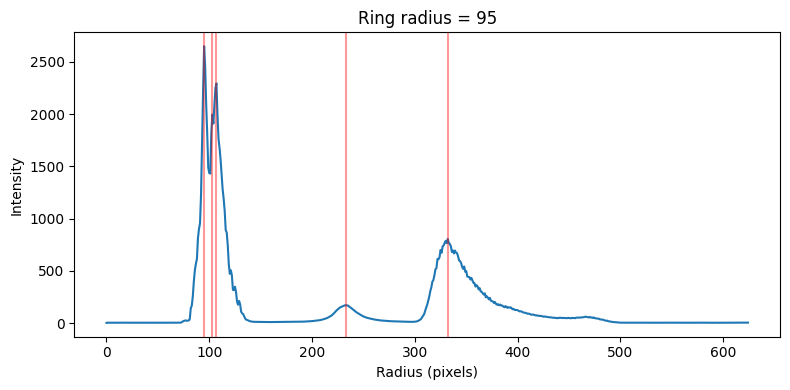

Peaks: [ 95 103 107 233 332]
Ring radius = 233


In [49]:
# find the ring radius from the radial profile

y, x = np.indices(avg.shape)

r = np.sqrt((x - cx)**2 + (y - cy)**2)
r_int = r.astype(int)

radial_sum = np.bincount(r_int.ravel(), weights=avg.ravel())
radial_count = np.bincount(r_int.ravel())
radial_profile = radial_sum / radial_count

peak_prom = 0.20
peaks, props = find_peaks(
    radial_profile,
    prominence=np.std(radial_profile) * peak_prom
)

ring_radius = peaks[np.argmax(props["prominences"])]

plt.figure(figsize=(8, 4))
plt.plot(radial_profile)

for p in peaks:
    plt.axvline(p, color="r", alpha=0.4)

plt.xlabel("Radius (pixels)")
plt.ylabel("Intensity")
plt.title(f"Ring radius = {ring_radius}")
plt.tight_layout()
plt.show()

ring_radius = 233 #to pick value manually

print("Peaks:", peaks)
print("Ring radius =", ring_radius)

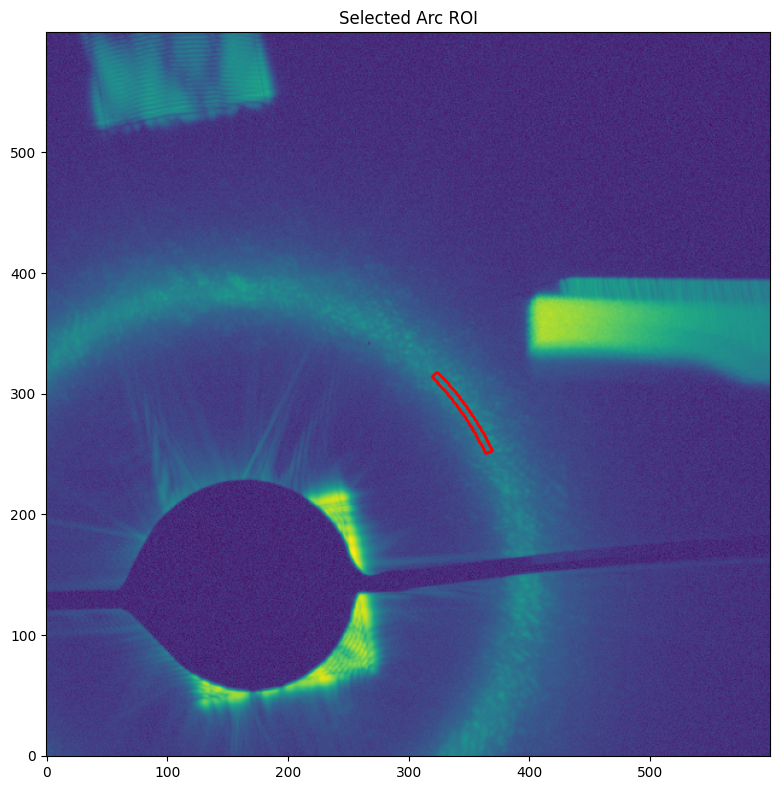

ROI pixels: 472


In [59]:
# choose the arc ROI on the ring

# manual override if needed
ring_radius = 228

theta = np.arctan2(y - cy, x - cx)

theta_min = np.radians(25)
theta_max = np.radians(45)

arc_roi = (
    (r > ring_radius - 3) &
    (r < ring_radius + 3) &
    (theta > theta_min) &
    (theta < theta_max)
)

plt.figure(figsize=(8, 8))
plt.imshow(np.log10(avg + 1), origin="lower")
plt.contour(arc_roi, colors="red", linewidths=2)
#plt.colorbar(label="log10(counts + 1)")
plt.title("Selected Arc ROI")
plt.tight_layout()
plt.show()

print("ROI pixels:", arc_roi.sum())

In [60]:
# choose temperature-dependent XPCS files

chosen_files = sorted(
    [
        f for f in files
        if "_XPCS_" in os.path.basename(f)
        and "1900images" in os.path.basename(f)
    ],
    key=get_temp
)

print("Chosen files:")
for i, f in enumerate(chosen_files):
    print(f"{i:3d} : {get_temp(f):.0f} K : {os.path.basename(f)}")

Chosen files:
  0 : 350 K : FCGT_350K_XPCS_300ms_1900images_640readout_681083c8-1049-4181-92ae-5a89e07969d8.h5
  1 : 355 K : FCGT_355K_XPCS_300ms_1900images_640readout_19ccc0d3-79e7-4fd8-b5a3-aefc582d5bc0.h5
  2 : 360 K : FCGT_360K_XPCS_300ms_1900images_640readout_cd9caa08-abba-4fcd-be88-7cc2f0a4d36c.h5
  3 : 362 K : FCGT_362K_XPCS_300ms_1900images_640readout_a96aa249-fc0b-47ee-90e1-583a86cdb4cb.h5
  4 : 363 K : FCGT_363K_XPCS_300ms_1900images_640readout_310d3268-f4c8-48b6-9cb6-9bcc8161909a.h5


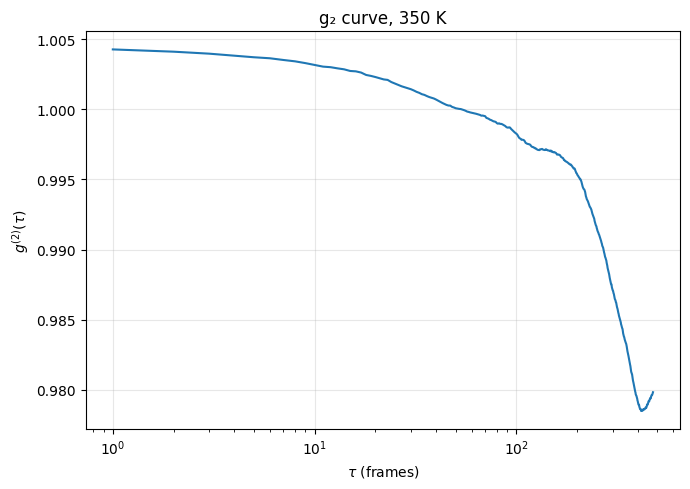

File: FCGT_350K_XPCS_300ms_1900images_640readout_681083c8-1049-4181-92ae-5a89e07969d8.h5
Mean signal: 221
Cell took 5.58 s


In [44]:
# g2 for temperature file index 0

if len(chosen_files) > 0:
    tau_0, g2_0, signal_0 = plot_g2_for_file(
        chosen_files[0],
        arc_roi,
        max_tau=None
    )
else:
    print("No file at index 0.")

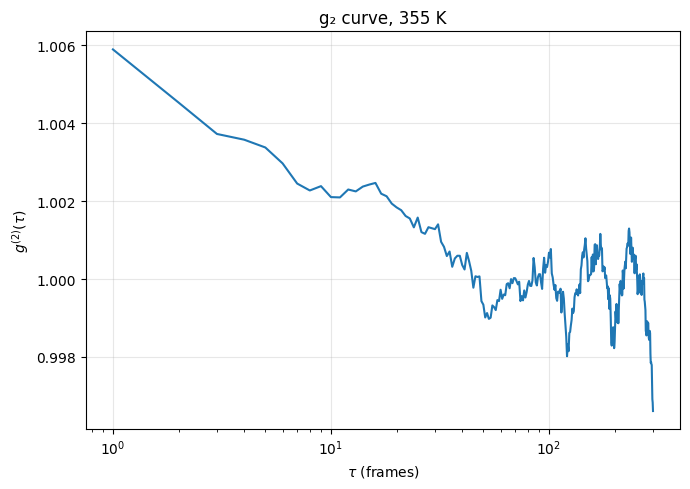

File: FCGT_355K_XPCS_300ms_1900images_640readout_19ccc0d3-79e7-4fd8-b5a3-aefc582d5bc0.h5
Mean signal: 159
Cell took 4.00 s


In [61]:
# g2 for temperature file index 1

if len(chosen_files) > 1:
    tau_1, g2_1, signal_1 = plot_g2_for_file(
        chosen_files[1],
        arc_roi,
        max_tau=300
    )
else:
    print("No file at index 1.")


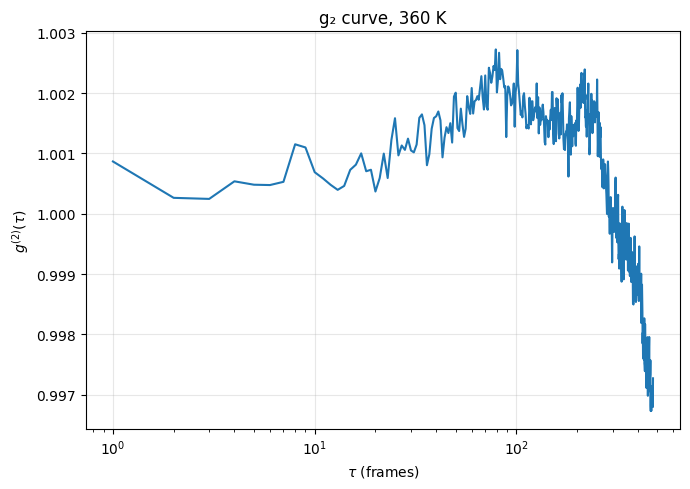

File: FCGT_360K_XPCS_300ms_1900images_640readout_cd9caa08-abba-4fcd-be88-7cc2f0a4d36c.h5
Mean signal: 31.1
Cell took 5.21 s


In [62]:
# g2 for temperature file index 2

if len(chosen_files) > 2:
    tau_2, g2_2, signal_2 = plot_g2_for_file(
        chosen_files[2],
        arc_roi,
        max_tau=None
    )
else:
    print("No file at index 2.")

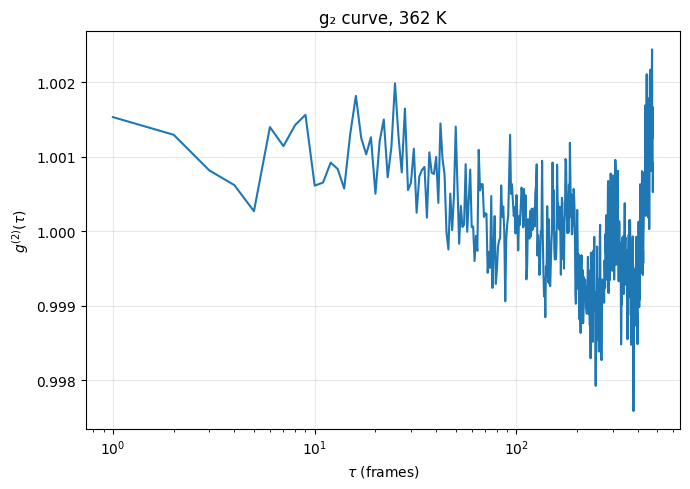

File: FCGT_362K_XPCS_300ms_1900images_640readout_a96aa249-fc0b-47ee-90e1-583a86cdb4cb.h5
Mean signal: 17.9
Cell took 5.41 s


In [63]:
# g2 for temperature file index 3

if len(chosen_files) > 3:
    tau_3, g2_3, signal_3 = plot_g2_for_file(
        chosen_files[3],
        arc_roi,
        max_tau=None
    )
else:
    print("No file at index 3.")

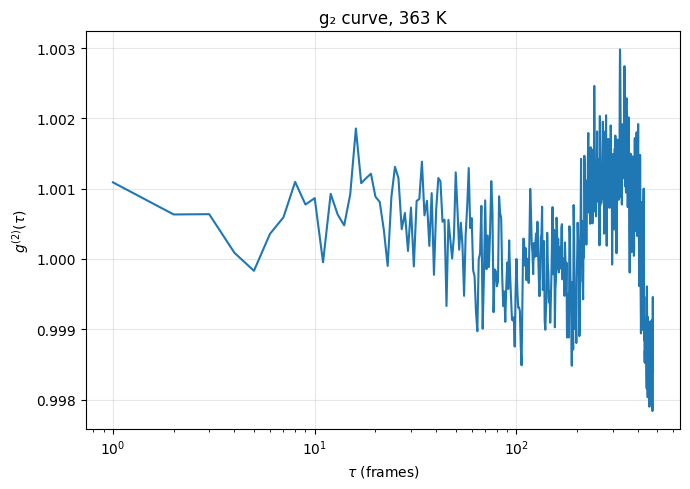

File: FCGT_363K_XPCS_300ms_1900images_640readout_310d3268-f4c8-48b6-9cb6-9bcc8161909a.h5
Mean signal: 13.5
Cell took 4.99 s


In [64]:
# g2 for temperature file index 4

if len(chosen_files) > 4:
    tau_4, g2_4, signal_4 = plot_g2_for_file(
        chosen_files[4],
        arc_roi,
        max_tau=None
    )
else:
    print("No file at index 4.")

Speckles found: 13


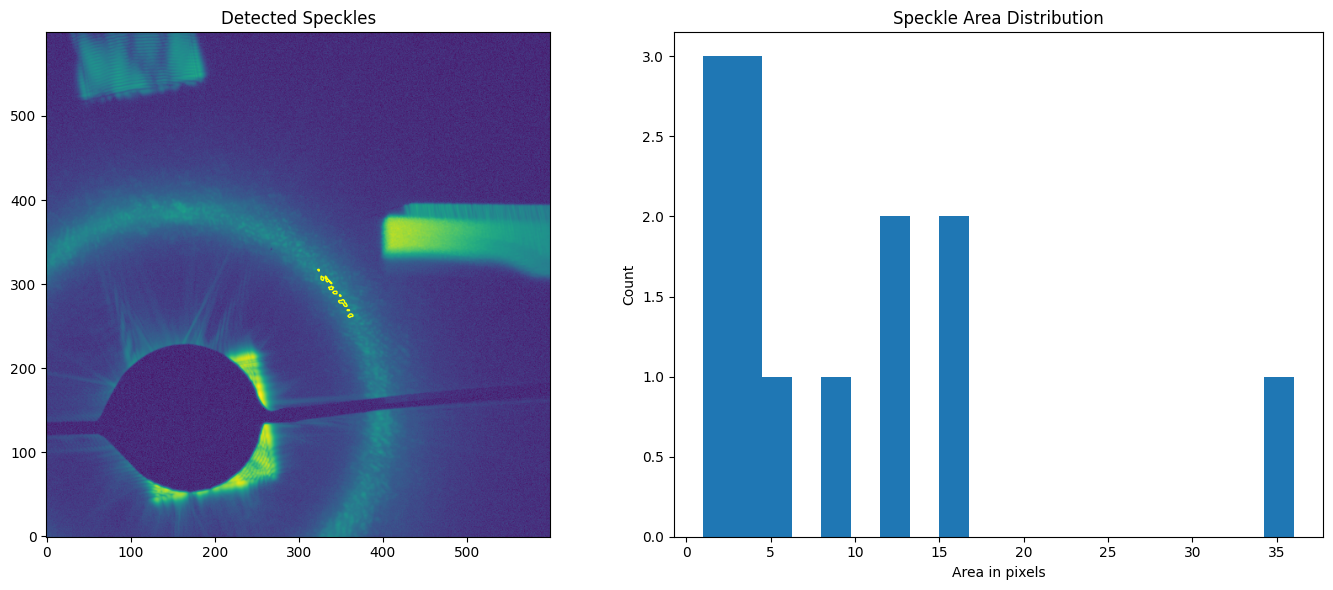

In [65]:
# find bright speckles in the selected arc

arc_image = avg.copy()
arc_image[~arc_roi] = 0

speckle_threshold = np.percentile(arc_image[arc_roi], 75)
speckles = arc_image > speckle_threshold

labels, nlabels = ndimage.label(speckles)

areas = ndimage.sum(
    speckles,
    labels,
    range(1, nlabels + 1)
)

print("Speckles found:", nlabels)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(np.log10(avg + 1), origin="lower")
ax[0].contour(labels > 0, colors="yellow", linewidths=1)
ax[0].set_title("Detected Speckles")

ax[1].hist(areas, bins=20)
ax[1].set_xlabel("Area in pixels")
ax[1].set_ylabel("Count")
ax[1].set_title("Speckle Area Distribution")

plt.tight_layout()
plt.show()

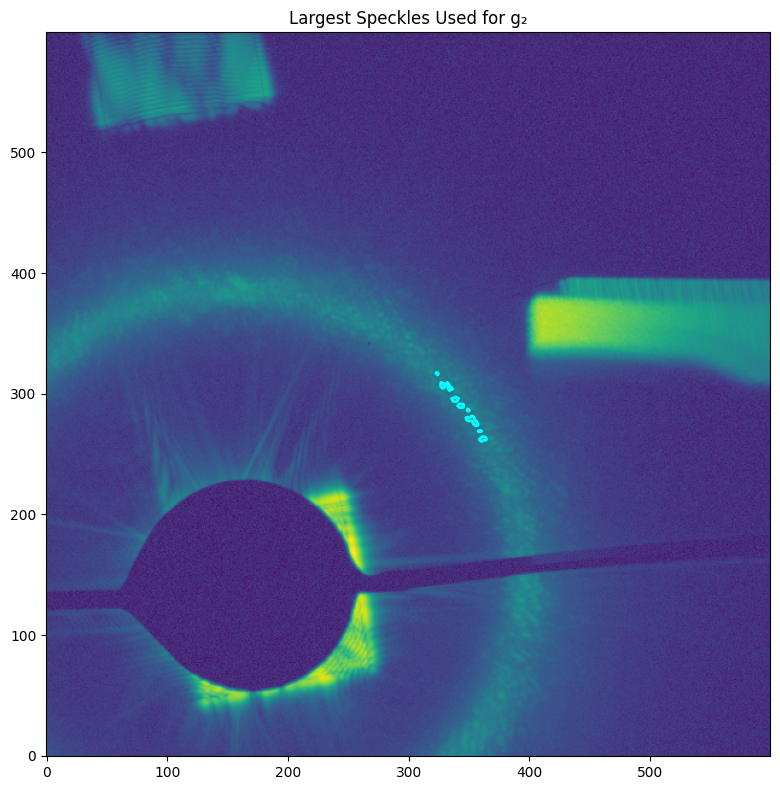

Speckles used: 10


In [66]:
# choose the largest speckles

n_speckles_to_use = 10

largest = np.argsort(areas)[-n_speckles_to_use:] + 1
largest_mask = np.isin(labels, largest)

plt.figure(figsize=(8, 8))
plt.imshow(np.log10(avg + 1), origin="lower")
plt.contour(largest_mask, colors="cyan", linewidths=2)
#plt.colorbar(label="log10(counts + 1)")
plt.title("Largest Speckles Used for g₂")
plt.tight_layout()
plt.show()

print("Speckles used:", len(largest))

In [67]:
# make one small ROI mask for each selected speckle

speckle_masks = []
speckle_coords = []

for speckle_id in largest:
    mask = labels == speckle_id
    cy_sp, cx_sp = ndimage.center_of_mass(mask)

    speckle_masks.append(mask)
    speckle_coords.append((speckle_id, cx_sp, cy_sp))

print(" ID     x        y")
for speckle_id, x_sp, y_sp in speckle_coords:
    print(f"{speckle_id:3d}  {x_sp:7.1f}  {y_sp:7.1f}")

 ID     x        y
  2    359.0    269.0
  4    349.3    286.3
 13    323.7    316.7
 12    332.4    307.8
  9    334.2    304.4
 11    328.0    306.8
  5    343.3    290.0
  6    338.5    295.3
  1    361.6    262.6
  3    352.8    277.8


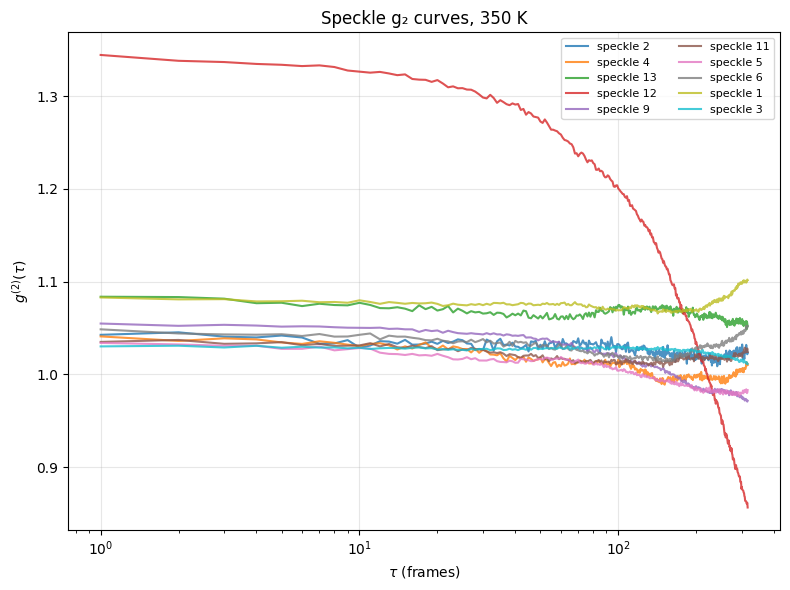

Finished.


In [69]:
# plot g2 curves for the selected speckles in one chosen temperature file

speckle_g2_file_index = 0  # change this to pick a different temperature
speckle_file = chosen_files[speckle_g2_file_index]

plt.figure(figsize=(8, 6))

for speckle_id, mask in zip(largest, speckle_masks):
    signal = roi_signal_from_file(speckle_file, mask)
    tau, g2_curve = g2_fft_local(signal)

    plt.semilogx(tau, g2_curve, alpha=0.8, label=f"speckle {speckle_id}")

plt.xlabel(r"$\tau$ (frames)")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.title(f"Speckle g₂ curves, {get_temp(speckle_file):.0f} K")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print("Finished.")

In [53]:
# fast g2 using the equation with local normalization
def g2_fft_local(signal, max_tau=None):
    import numpy as np

    signal = np.asarray(signal, dtype=float)
    signal = signal[np.isfinite(signal)]

    N = len(signal)

    if max_tau is None:
        max_tau = N // 6   # avoids very noisy long tau values

    max_tau = min(max_tau, N - 2)

    # numerator: <I(t) I(t+tau)>
    f = signal - np.mean(signal)
    fft = np.fft.fft(f, n=2*N)
    acov = np.fft.ifft(fft * np.conjugate(fft)).real[:max_tau+1]

    # convert covariance back to <I(t)I(t+tau)>
    mean_I = np.mean(signal)
    numerator = acov / (N - np.arange(max_tau+1)) + mean_I**2

    # denominator: <I(t)> <I(t+tau)> for each tau
    cumsum = np.concatenate([[0], np.cumsum(signal)])

    denom = np.empty(max_tau+1)

    for tau in range(max_tau+1):
        left_mean = (cumsum[N-tau] - cumsum[0]) / (N - tau)
        right_mean = (cumsum[N] - cumsum[tau]) / (N - tau)
        denom[tau] = left_mean * right_mean

    g2 = numerator / denom

    taus = np.arange(max_tau+1)

    return taus[1:], g2[1:]